In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/r4n99angro/ini-dataset/sepsis_emr_data.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/r4n99angro/ini-dataset/sepsis_emr_data.csv')

In [3]:
df.head()

,patient_id,heart_rate,respiratory_rate,temperature,wbc_count,lactate_level,age,num_comorbidities,sepsis_risk
0,PID0001,88,17,37.1,7.9,1.1,51,1,0
1,PID0002,115,25,38.6,16.0,3.6,78,3,1
2,PID0003,79,16,36.9,7.1,0.9,42,0,0
3,PID0004,96,20,37.5,10.2,1.6,65,2,0
4,PID0005,122,29,39.2,18.1,4.7,83,4,1


In [4]:
df.columns

Index(['patient_id', 'heart_rate', 'respiratory_rate', 'temperature',
       'wbc_count', 'lactate_level', 'age', 'num_comorbidities',
       'sepsis_risk'],
      dtype='object')

In [5]:
df = df[['heart_rate', 'respiratory_rate', 'temperature',
       'wbc_count', 'lactate_level', 'age', 'num_comorbidities',
       'sepsis_risk']]

In [6]:
korelasi = df.corr()
print(korelasi)

                   heart_rate  respiratory_rate  temperature  wbc_count  \
heart_rate           1.000000          0.734811     0.518670   0.735001   
respiratory_rate     0.734811          1.000000     0.693392   0.992777   
temperature          0.518670          0.693392     1.000000   0.701010   
wbc_count            0.735001          0.992777     0.701010   1.000000   
lactate_level        0.702167          0.992458     0.662840   0.987578   
age                  0.738159          0.952295     0.690067   0.962558   
num_comorbidities    0.743615          0.948173     0.698983   0.950155   
sepsis_risk          0.624851          0.878223     0.634245   0.901335   

                   lactate_level       age  num_comorbidities  sepsis_risk  
heart_rate              0.702167  0.738159           0.743615     0.624851  
respiratory_rate        0.992458  0.952295           0.948173     0.878223  
temperature             0.662840  0.690067           0.698983     0.634245  
wbc_count       

In [7]:
print(df.isnull().sum())

heart_rate             0
respiratory_rate       0
temperature            0
wbc_count              0
lactate_level        141
age                    0
num_comorbidities      0
sepsis_risk            0
dtype: int64


In [8]:
# Menghapus hanya baris yang memiliki nilai NaN di kolom 'lactate_level'
df_clean = df.dropna(subset=['lactate_level'])

# Cek kembali apakah masih ada null
print(df_clean.isnull().sum())

heart_rate           0
respiratory_rate     0
temperature          0
wbc_count            0
lactate_level        0
age                  0
num_comorbidities    0
sepsis_risk          0
dtype: int64


In [9]:
df.shape

(1753, 8)

In [16]:
jumlah_masing_masing_trgt2 = df_clean['sepsis_risk'].value_counts()
print('Jawaban Lain:', jumlah_masing_masing_trgt2)

Jawaban Lain: sepsis_risk
0    876
1    736
Name: count, dtype: int64


In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

In [42]:
from sklearn.model_selection import train_test_split

# 1. Pastikan indeks bersih (reset) setelah dropna/fill
df_clean = df_clean.reset_index(drop=True)

# 2. Pisahkan Fitur (X) dan Target (y)
X = df_clean.drop(columns=['sepsis_risk'])
y = df_clean['sepsis_risk']


X_scaled_array = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns, index=X.index)

# 4. SPLIT: 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)         


# Cek jumlah data
print(f"Total Data: {len(df)}")
print(f"Data Training: {len(X_train)}")
print(f"Data Testing: {len(X_test)}")

Total Data: 1753
Data Training: 1289
Data Testing: 323


In [36]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd

# 1. Fungsi untuk SMOTE (Oversampling)
def apply_smote(X_train, y_train):
    """
    Meningkatkan jumlah sampel minoritas agar seimbang dengan mayoritas.
    Cocok jika data Anda sedikit.
    """
    smote = SMOTE(random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
    
    print("Setelah SMOTE:")
    print(pd.Series(y_resampled).value_counts())
    return X_resampled, y_resampled

# 2. Fungsi untuk Undersampling
def apply_undersampling(X_train, y_train):
    """
    Mengurangi jumlah sampel mayoritas agar seimbang dengan minoritas.
    Cocok jika data Anda sangat besar (ribuan/jutaan baris).
    """
    rus = RandomUnderSampler(random_state=42)
    X_resampled, y_resampled = rus.fit_resample(X_train, y_train)
    
    print("Setelah Undersampling:")
    print(pd.Series(y_resampled).value_counts())
    return X_resampled, y_resampled


In [37]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

def build_xgboost(X_train, y_train, X_test, y_test):
    # 1. Inisialisasi Model
    # scale_pos_weight: Gunakan jika data masih tidak seimbang (Rasio Mayoritas/Minoritas)
    model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )

    # 2. Training Model
    model.fit(X_train, y_train)

    # 3. Prediksi
    y_pred = model.predict(X_test)

    # 4. Evaluasi Hasil
    print("--- Laporan Klasifikasi ---")
    print(classification_report(y_test, y_pred))
    
    # Visualisasi Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix - XGBoost')
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.show()

    return model

Setelah SMOTE:
sepsis_risk
0    700
1    700
Name: count, dtype: int64
--- Laporan Klasifikasi ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       176
           1       1.00      1.00      1.00       147

    accuracy                           1.00       323
   macro avg       1.00      1.00      1.00       323
weighted avg       1.00      1.00      1.00       323



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:41:48] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


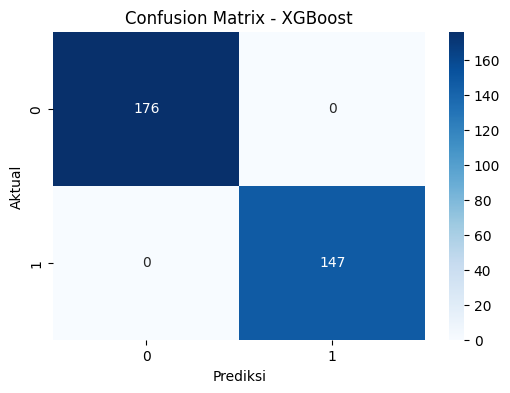

In [44]:
X_smt, y_smt = apply_smote(X_train, y_train)
model = build_xgboost(X_smt, y_smt, X_test, y_test)

In [60]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# List untuk menampung hasil evaluasi
ensemble_accuracies = []

In [62]:
model_xgb = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    # 1. Ambil data asli untuk fold ini
    X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]
    
    # 2. Panggil fungsi SMOTE Anda (HANYA untuk data training fold ini)
    X_train_res, y_train_res = apply_smote(X_train_fold, y_train_fold)
    
    # 3. TRAIN MODEL (Harus di sini agar model belajar dari data yang sudah di-SMOTE)
    model_xgb.fit(X_train_res, y_train_res)
    
    # 4. EVALUASI (Gunakan data test fold ini yang MASIH ASLI)
    score = model_xgb.score(X_test_fold, y_test_fold)
    print(f"Akurasi Fold {fold+1}: {score}")

Setelah SMOTE:
sepsis_risk
0    700
1    700
Name: count, dtype: int64
Akurasi Fold 1: 1.0
Setelah SMOTE:
sepsis_risk
0    701
1    701
Name: count, dtype: int64
Akurasi Fold 2: 1.0
Setelah SMOTE:
sepsis_risk
1    701
0    701
Name: count, dtype: int64
Akurasi Fold 3: 1.0
Setelah SMOTE:
sepsis_risk
0    701
1    701
Name: count, dtype: int64
Akurasi Fold 4: 1.0
Setelah SMOTE:
sepsis_risk
0    701
1    701
Name: count, dtype: int64
Akurasi Fold 5: 1.0


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:06:02] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:06:02] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:06:02] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:06:02] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:06:02] WARNING: /w

In [48]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import numpy as np

# 1. Inisialisasi Stratified K-Fold yang benar (n_splits)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Tentukan Metrik yang Ingin Dilaporkan
scoring = {
    'auc_roc': 'roc_auc',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

# 3. Jalankan Cross Validation menggunakan data SMOTE
# Pastikan variabel model, X_train_smt, dan y_train_smt sudah terdefinisi
results = cross_validate(model, X_train_smt, y_train_smt, cv=skf, scoring=scoring)

# 4. Melaporkan Hasil dengan Tabel Rapi
print("=== HASIL EVALUASI K-FOLD CROSS-VALIDATION ===")
print(f"{'Metrik':<15} | {'Rata-rata':<10} | {'Standar Deviasi':<15}")
print("-" * 45)
print(f"{'AUC-ROC':<15} | {np.mean(results['test_auc_roc']):.4f}    | {np.std(results['test_auc_roc']):.4f}")
print(f"{'Precision':<15} | {np.mean(results['test_precision']):.4f}    | {np.std(results['test_precision']):.4f}")
print(f"{'Recall':<15} | {np.mean(results['test_recall']):.4f}    | {np.std(results['test_recall']):.4f}")
print(f"{'F1-Score':<15} | {np.mean(results['test_f1']):.4f}    | {np.std(results['test_f1']):.4f}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:45:39] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:45:39] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:45:39] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:45:39] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:45:39] WARNING: /w

=== HASIL EVALUASI K-FOLD CROSS-VALIDATION ===
Metrik          | Rata-rata  | Standar Deviasi
---------------------------------------------
AUC-ROC         | 1.0000    | 0.0000
Precision       | 1.0000    | 0.0000
Recall          | 1.0000    | 0.0000
F1-Score        | 1.0000    | 0.0000


In [49]:
import joblib

# Simpan model ke dalam file .pkl
joblib.dump(model, 'model_sepsis_xgboost.pkl')

# Simpan juga scaler-nya (PENTING: agar data baru nanti di-scale dengan parameter yang sama)
joblib.dump(scaler, 'scaler_sepsis.pkl')

print("Model dan Scaler berhasil disimpan!")

Model dan Scaler berhasil disimpan!


In [50]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Inisialisasi Model
ann_model = Sequential()

# Input Layer & Hidden Layer 1
# input_dim disesuaikan dengan jumlah kolom fitur Anda
ann_model.add(Dense(units=16, activation='relu', input_dim=X_train_smt.shape[1]))
ann_model.add(Dropout(0.2)) # Untuk mencegah overfitting

# Hidden Layer 2
ann_model.add(Dense(units=8, activation='relu'))

# Output Layer (Sigmoid karena targetnya biner: 0 atau 1)
ann_model.add(Dense(units=1, activation='sigmoid'))

# Compile Model
ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

ann_model.summary()

2026-02-22 13:48:23.835713: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771768104.100677     276 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771768104.178971     276 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771768104.749699     276 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771768104.749792     276 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771768104.749796     276 computation_placer.cc:177] computation placer alr

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273 (1.07 KB)

 Trainable params: 273 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
history = ann_model.fit(
    X_train_smt, y_train_smt, 
    epochs=50, 
    batch_size=32, 
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5136 - loss: 0.6481 - val_accuracy: 0.6068 - val_loss: 0.5990
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6497 - loss: 0.5698 - val_accuracy: 0.7616 - val_loss: 0.5370
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7725 - loss: 0.5151 - val_accuracy: 0.8173 - val_loss: 0.4836
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7995 - loss: 0.4768 - val_accuracy: 0.8173 - val_loss: 0.4360
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8252 - loss: 0.4375 - val_accuracy: 0.8359 - val_loss: 0.3832
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8809 - loss: 0.3864 - val_accuracy: 0.9443 - val_loss: 0.3285
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9208 - loss: 0.3255 - val_accuracy: 0.9876 - val_loss: 0.2774
Epoch 8/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9454 - loss: 0.2871 - val_accuracy: 0.9876 - val_loss:

In [52]:
from sklearn.metrics import classification_report

# Prediksi (ANN mengembalikan probabilitas, jadi kita bulatkan di atas 0.5)
y_pred_ann = (ann_model.predict(X_test) > 0.5).astype("int32")

print(classification_report(y_test, y_pred_ann))

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       176
           1       0.99      1.00      0.99       147

    accuracy                           0.99       323
   macro avg       0.99      0.99      0.99       323
weighted avg       0.99      0.99      0.99       323



In [53]:
# Simpan model ANN
ann_model.save('model_sepsis_ann.keras')

print("Model ANN berhasil disimpan dalam format .keras")

Model ANN berhasil disimpan dalam format .keras


In [56]:
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score

# 1. Ambil probabilitas untuk kelas 1 (Sepsis)
# XGBoost: predict_proba mengembalikan [prob_0, prob_1]
y_prob_xgb = model.predict_proba(X_test)[:, 1]

# ANN: predict mengembalikan probabilitas langsung (karena menggunakan sigmoid)
y_prob_ann = ann_model.predict(X_test).flatten()

# 2. Tentukan Bobot (Weights)
# Contoh bobot: 50/50
w_xgb = 0.5
w_ann = 0.5

# 3. Hitung Weighted Average Probability
y_prob_ensemble = (w_xgb * y_prob_xgb) + (w_ann * y_prob_ann)

# 4. Tentukan Prediksi Akhir berdasarkan threshold 0.5
y_pred_ensemble = (y_prob_ensemble >= 0.5).astype(int)

# 5. Evaluasi Hasil Ensemble
print("=== EVALUASI SOFT VOTING ENSEMBLE (50/50) ===")
print(classification_report(y_test, y_pred_ensemble))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob_ensemble):.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
=== EVALUASI SOFT VOTING ENSEMBLE (50/50) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       176
           1       1.00      1.00      1.00       147

    accuracy                           1.00       323
   macro avg       1.00      1.00      1.00       323
weighted avg       1.00      1.00      1.00       323

AUC-ROC Score: 1.0000


In [5]:
print(list(X_train.columns))

NameError: name 'X_train' is not defined